# Part 2: Image classification with CNNs

In [1]:
import numpy as np

# Data handling
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
import sklearn
import torch # Our new deep learning package!

# Data Loading
from torch.utils.data import Dataset, DataLoader

# Model building
import torch.nn as nn
import torch.nn.functional as F

# Training
import torch.optim as optim
import torchvision.transforms as transforms

Use the same random seed throughout this notebook.

In [2]:
random_seed = 42

#### Discussion 1
* Given that you have already trained a CNN on the MNIST dataset, how is training a CNN different from what we did for the SVM?

## 1: Load the training data.

Load the training data as before and add missing column labels.

In [3]:
df_digits = pd.read_csv('mnist_train.csv',header=None)
col_labels = ['label'] + [f'pixel_{i:03d}' for i in range(784)]
df_digits.columns = col_labels
df_digits.head()

,label,pixel_000,pixel_001,pixel_002,pixel_003,pixel_004,pixel_005,pixel_006,pixel_007,pixel_008,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2: Prepare data for training

In [4]:
# Separate features (pixel values) from labels; be sure they are arrays and not pandas Series
pixel_values = df_digits.drop('label',axis=1).values / 255 # Normalize between 0 and 1
labels = df_digits['label'].values

# Reshape so channel comes first (N_examples, 784) -> (N_examples, 1, 28, 28)
pixel_values = np.reshape(pixel_values, (-1, 1, 28, 28)).astype(np.float32)
labels = labels.astype(np.int64)

# Train / validation split
pixels_train, pixels_val, labels_train, labels_val = sklearn.model_selection.train_test_split(pixel_values, labels,
                                                                                             train_size=0.85,
                                                                                             stratify=labels,
                                                                                             random_state=random_seed)

### 2.1: Create custom dataset class.

We need to create our own kind of object for handling the data.

This is because PyTorch's `DataLoader` expects objects with three methods:
* `__init__` -> Store the data as tensors (accessed as features of self)
* `__len__` -> How many samples?
* `__getitem__` -> return a single sample

By passing `Dataset` as the argument for the class, it "inherits" properties of the `Dataset` object we imported at the top of this script.

In [5]:
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

We now use this `MNISTDataset` class to make our datasets and pass them to PyTorch's `DataLoader`. The `DataLoader` can make shuffled batches of your dataset that you use in each epoch of training.

Note that as before, we separate training and validation data, and we do not shuffle the validation data, as we want a similar comparison each time.

In [6]:
batch_size = 128
train_dataset = MNISTDataset(pixels_train, labels_train)
val_dataset = MNISTDataset(pixels_val, labels_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## 3: Create the CNN as a custom class

Here we define our CNN class, though with slightly different syntax and architecture than before. 

In [7]:
class CNN(nn.Module): # Inherit important methods from PyTorch's nn.Module class
    def __init__(self): # Constructor of our class, specify what to run when object is instantiated
        # Define methods for this object that define the architecture of the neural network
        
        super(CNN, self).__init__() # Calls constructor of the parent class, nn.Module
        # Conv Block 1: 1→32 channels
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)   # 28x28 → 28x28; 1 channel becomes 32 outputs with a 3x3 kernel, padding of 1 pixel to preserve dimensions
        self.pool1 = nn.MaxPool2d(2, 2)               # 28x28 → 14x14; take max value of every 2x2 region
        self.drop1 = nn.Dropout2d(0.25)               # Random dropout
        
        # Conv Block 2: 32→64 channels  
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # 14x14 → 14x14
        self.pool2 = nn.MaxPool2d(2, 2)               # 14x14 → 7x7
        self.drop2 = nn.Dropout2d(0.25)
        
        # Classifier
        self.fc1 = nn.Linear(64 * 7 * 7, 128)         # 3136 → 128
        self.drop3 = nn.Dropout(0.5)                  # higher dropout as fully connected layer more prone to overfitting with larger number of parameters
        self.fc2 = nn.Linear(128, 10)                 # 128 → 10 digits
    
    def forward(self, x):
        # apply the methods defined above in order to input features X to produce output classification
        
        # Block 1
        x = F.relu(self.conv1(x))        # Applies ReLU activation to the output of `conv1` method (i.e., zeroes negative values, introduces some nonlinearity)
        x = self.pool1(x)
        x = self.drop1(x)
        
        # Block 2
        x = F.relu(self.conv2(x)) 
        x = self.pool2(x)
        x = self.drop2(x)
        
        # Classifier
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x

Instantiate the model object.

In [8]:
# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)

print(f"Using device: {device}")
print(model)

Using device: cuda
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout2d(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (drop3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4: Train the CNN

For training, we use an optimizer to iteratively update the weights of our neural network to reduce the loss (i.e., error). In each epoch, the full training dataset is divided into batches, and the weights are updated over each batch.

Important features here:
* Number of epochs: how many iterations to do over the full training set
* Loss: How is error calculated? Here, are outputs are normalized like probabilities between 0 and 1, so we take the `CrossEntropyLoss` or the negative log of the probability (0 for full confidence of 1, and larger as probabilities get small)
* Optimizer: which function to use for weight updates
* Learning rate: how aggressively the optimizer updates the weights

In [9]:
# How long to train form
num_epochs = 10

# Our loss function
criterion = nn.CrossEntropyLoss()

# Our optimizer
learning_rate = 0.001
optimizer = optim.AdamW(model.parameters(), 
                       lr=learning_rate)

Now, we run the training.

In [10]:
# Keep track during each epoch of the training loss and validation accuracy
train_losses, val_accuracies = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    # Images and labels are part of `train_loader`, which we also instantiated above
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    train_losses.append(epoch_loss)
    val_accuracies.append(epoch_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs}: Loss={epoch_loss:.4f}, Val Acc={epoch_acc:.4f}')

Epoch 1/10: Loss=0.4583, Val Acc=0.9681
Epoch 2/10: Loss=0.1609, Val Acc=0.9783
Epoch 3/10: Loss=0.1172, Val Acc=0.9823
Epoch 4/10: Loss=0.1008, Val Acc=0.9859
Epoch 5/10: Loss=0.0881, Val Acc=0.9859
Epoch 6/10: Loss=0.0809, Val Acc=0.9867
Epoch 7/10: Loss=0.0736, Val Acc=0.9881
Epoch 8/10: Loss=0.0659, Val Acc=0.9880
Epoch 9/10: Loss=0.0616, Val Acc=0.9884
Epoch 10/10: Loss=0.0539, Val Acc=0.9883


Highest validation accuracy: 0.9884


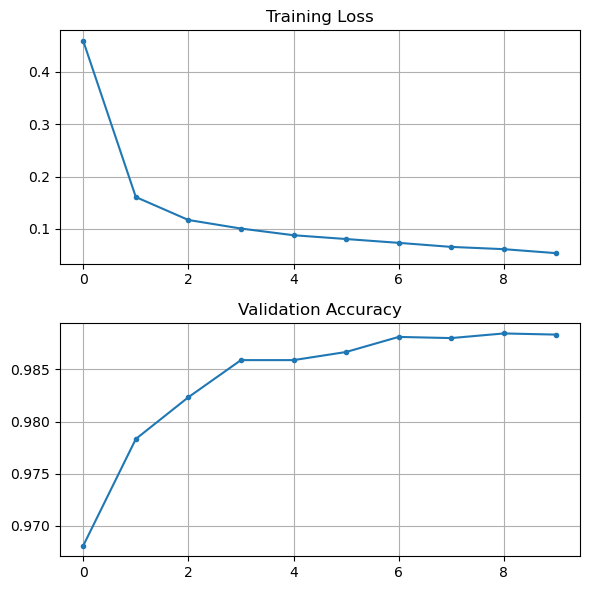

In [11]:
# Plot training curves
fig, axes = plt.subplots(2,1, figsize=(6,6))
axes[0].plot(train_losses,'.-')
axes[0].set_title('Training Loss')
axes[0].grid()

axes[1].plot(val_accuracies,'.-')
axes[1].set_title('Validation Accuracy')
plt.tight_layout()
axes[1].grid()

print(f'Highest validation accuracy: {np.max(val_accuracies):.4f}')

As expected, the training loss decreases with every epoch, as that is explicitly what we use to update the weights (i.e., the gradient of the loss). However, the validation accuracy does not always increase - some model updates improve fitting of the training but have lower accuracy in the validation data (i.e., have signs of overfitting).

From curves like this, we can pick the epoch that produced the best results, i.e., highest validation accuracy. When I ran this model, I got 0.9889 validation accuracy, technically higher than the 0.9858 accuracy I got from my best SVM.

Remember that, to really report model accuracy, we would use our held-out test data.

#### Discussion 2
* Is this model good?
* How would you improve your model performance? (For fun, try to brainstorm without reading ahead in the notebook.)

## 5: Improving training

As you have seen in the SVM tutorial, most of machine learning implements some kind of optimization algorithm. But these are not only stochastic (give different results for different random seeds), but they are also sensitive to how you optimize (e.g., the constraints and hyperparameters of the optimization). Therefore, you can get better models not just by changing the model architecture or what data you train on, but also how you choose to do the training. You might also want to fine tune your training to get faster convergence, just to make model fitting faster.

Here we will explore the effect of some choices you can make.

### 5.1: Changes to learning rate

Recall that for the `AdamW` optimizer (and most others), the learning rate is multiplied by the gradient when the weights are updated. It works almost like a "step size" as we explore the loss landscape. But are higher learning rates better?

In [12]:
# Key parameters
learning_rates = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
num_epochs = 20

# Our loss function
criterion = nn.CrossEntropyLoss()

In [13]:
train_losses_lr_screen = {learning_rate: [] for learning_rate in learning_rates}
val_accuracies_lr_screen = {learning_rate: [] for learning_rate in learning_rates}

for learning_rate in learning_rates:

    print(f"Learning rate: {learning_rate}")

    # Instantiate the model
    model = CNN().to(device)
    
    # Our optimizer
    # Parameters are a feature of the model object, instantiated before
    optimizer = optim.AdamW(model.parameters(), 
                           lr=learning_rate)
    
    # Keep track during each epoch of the training loss and validation accuracy
    train_losses, val_accuracies = [], []
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        # Images and labels are part of `train_loader`, which we also instantiated above
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        
        train_losses.append(epoch_loss)
        val_accuracies.append(epoch_acc)

        if (epoch+1)%5==0:
            print(f'Epoch {epoch+1}/{num_epochs}: Loss={epoch_loss:.4f}, Val Acc={epoch_acc:.4f}')

    train_losses_lr_screen[learning_rate] = train_losses
    val_accuracies_lr_screen[learning_rate] = val_accuracies

Learning rate: 0.0001
Epoch 5/20: Loss=0.2093, Val Acc=0.9590
Epoch 10/20: Loss=0.1227, Val Acc=0.9752
Epoch 15/20: Loss=0.0924, Val Acc=0.9824
Epoch 20/20: Loss=0.0752, Val Acc=0.9839
Learning rate: 0.0003
Epoch 5/20: Loss=0.1161, Val Acc=0.9798
Epoch 10/20: Loss=0.0771, Val Acc=0.9860
Epoch 15/20: Loss=0.0531, Val Acc=0.9878
Epoch 20/20: Loss=0.0461, Val Acc=0.9889
Learning rate: 0.001
Epoch 5/20: Loss=0.0743, Val Acc=0.9892
Epoch 10/20: Loss=0.0465, Val Acc=0.9882
Epoch 15/20: Loss=0.0359, Val Acc=0.9909
Epoch 20/20: Loss=0.0283, Val Acc=0.9899
Learning rate: 0.003
Epoch 5/20: Loss=0.0870, Val Acc=0.9860
Epoch 10/20: Loss=0.0641, Val Acc=0.9879
Epoch 15/20: Loss=0.0564, Val Acc=0.9878
Epoch 20/20: Loss=0.0488, Val Acc=0.9892
Learning rate: 0.01
Epoch 5/20: Loss=0.2834, Val Acc=0.9680
Epoch 10/20: Loss=0.2284, Val Acc=0.9739
Epoch 15/20: Loss=0.2225, Val Acc=0.9754
Epoch 20/20: Loss=0.2161, Val Acc=0.9746


0.0001: max val. accuracy: 0.9839
0.0003: max val. accuracy: 0.9889
0.001: max val. accuracy: 0.9913
0.003: max val. accuracy: 0.9897
0.01: max val. accuracy: 0.9786


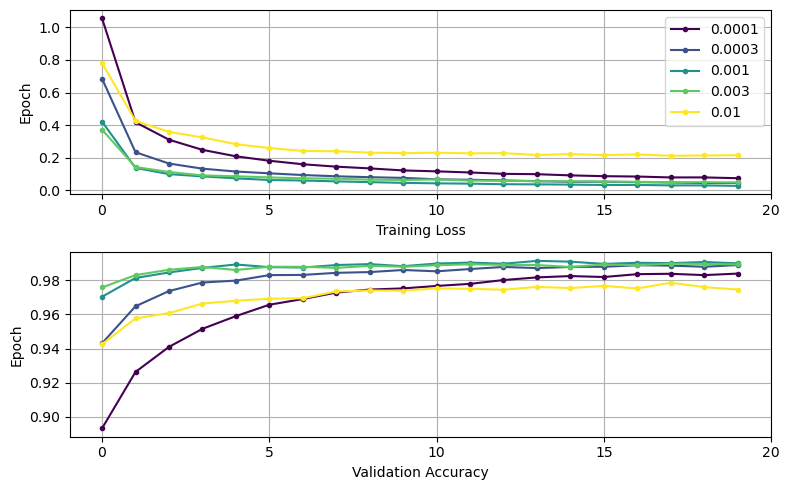

In [18]:
n_colors = len(learning_rates)
colors = plt.cm.viridis(np.linspace(0, 1, n_colors))

data_labels = ['Training Loss', 'Validation Accuracy']
fig, axes = plt.subplots(2,1, figsize=(8,5))

for d, data in enumerate([train_losses_lr_screen, val_accuracies_lr_screen]):
    # Plot training curves
    for l, learning_rate in enumerate(learning_rates):
        y = data[learning_rate]
        axes[d].plot(y,'.-',
                     label=f'{learning_rate}',
                    color=colors[l])

        if data_labels[d]=='Validation Accuracy':
            print(f'{learning_rate}: max val. accuracy: {np.max(y):.4f}')

    axes[d].grid()
    axes[d].set_xticks(np.arange(0,num_epochs+1, 5))

    axes[d].set_ylabel('Epoch')
    axes[d].set_xlabel(data_labels[d])

axes[0].legend()
plt.tight_layout()

We can already see the effect of higher learning rates after the first epoch, as those first round models tend to be more accurate if the learning rate is higher. And in early stages, improvements are also faster. However, when learning rate increases too much, accuracy is lost and even the slowest learning rate outpaces the faster one.

In [19]:
# n_colors = len(learning_rates)
# colors = plt.cm.viridis(np.linspace(0, 1, n_colors))

# data_labels = ['Training Loss', 'Validation Accuracy']

# for d, data in enumerate([train_losses_lr_screen, val_accuracies_lr_screen]):
#     # Plot training curves
#     fig, axes = plt.subplots(1,3, figsize=(8,3), sharey=True)

#     for l, learning_rate in enumerate(learning_rates):
#         y = data[learning_rate]
#         axes[0].plot(y,'.-',
#                      label=f'{learning_rate}',
#                     color=colors[l])
#         axes[1].bar(l, y[0], width=0.7, color=colors[l])
#         axes[2].bar(l, np.min(y), width=0.7, color=colors[l])
        
#     axes[0].set_ylabel(data_labels[d])
#     axes[0].set_xlabel('Epoch')
#     axes[0].legend()
#     axes[1].set_ylabel(f'{data_labels[d]}\nafter first epoch')
#     axes[2].set_ylabel(f'Best value\n{data_labels[d]}')

#     for i in [1,2]:
#         axes[i].set_xlabel('Learning rate')
#         axes[i].set_xticks(np.arange(len(learning_rates)), learning_rates, rotation=45)

#     plt.tight_layout()

### 5.2: Changes to optimizer

A lot of work has been done to improve optimizers over the years. While we omit the technical differences here, here is a brief overview of the most famous ones and their historical progression.

* **Stochastic gradient descent (SGD)**: Updates weights by the product of the learning rate and the gradient; but can be slow on flat or narrow loss surface and sensitive to learning rate choice
* **SGD with momentum**: Incorporates historical *direction* of gradient changes (i.e., second derivative of loss surface) to updates, so can converge better; but has an extra parameter (momentum, i.e., importance of gradient history relative to gradient at current location) to tune and can overshoot minima
* **RMSprop**: Adapts learning rate for each parameter by rescaling it to the historical squared gradient (i.e.,  *magnitude* of parameter updates)); handles varying gradients better but the squared gradient never reset and reduces learning rate late in training
* **Adam**: Combines momentum with per-parameter adaptive learning rate; but the heaviest in terms of additional computations for each batch of weight updates and has more parameters to optimize (though usually defaults work well)

In [ ]:
# Number of epochs
num_epochs = 10

# Different optimizers (learning rates optimized offline)
optimizers = {'SGD': lambda params: optim.SGD(params, lr=0.1),
              'SGD+momentum': lambda params: optim.SGD(params, lr=0.1, momentum=0.9),
              'RMSprop': lambda params: optim.RMSprop(params, lr=0.001),
              'Adam': lambda params: optim.AdamW(params, lr=0.001)
}

In [ ]:
# Store training loss and validation accuracy
train_losses_opt_screen = {optimizer_key: [] for optimizer_key in optimizers.keys()}
val_accuracies_opt_screen = {optimizer_key: [] for optimizer_key in optimizers.keys()}

# Iterate over different optimizers
for optimizer_key in optimizers.keys():

    print(f"Optimizer: {optimizer_key}")

    # Instantiate the model
    model = CNN().to(device)
    
    # Our optimizer
    # Parameters are a feature of the model object, instantiated before
    optimizer = optimizers[optimizer_key](model.parameters())
    
    # Keep track during each epoch of the training loss and validation accuracy
    train_losses, val_accuracies = [], []
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        # Images and labels are part of `train_loader`, which we also instantiated above
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        
        train_losses.append(epoch_loss)
        val_accuracies.append(epoch_acc)

        if (epoch+1)%5==0:
            print(f'Epoch {epoch+1}/{num_epochs}: Loss={epoch_loss:.4f}, Val Acc={epoch_acc:.4f}')

    train_losses_opt_screen[optimizer_key] = train_losses
    val_accuracies_opt_screen[optimizer_key] = val_accuracies

In [ ]:
# Plot training curves
fig, axes = plt.subplots(2,1, figsize=(6,6))

colors = ['tab:red','tab:orange','tab:green','tab:blue','tab:purple']

for o, optimizer_key in enumerate(optimizers.keys()):
    tl = train_losses_opt_screen[optimizer_key]
    axes[0].plot(tl,'.-',
                 label=f'{optimizer_key}',
                color=colors[o])
    
    va = val_accuracies_opt_screen[optimizer_key]
    axes[1].plot(va,'.-',
                color=colors[o])
    
    print(f'{optimizer_key}: max val. accuracy: {np.max(va):.4f}')

axes[0].set_title('Training Loss')
axes[0].legend()
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
for i in range(2):
    axes[i].grid()
    axes[i].set_xticks(np.arange(0,num_epochs+1, step=5))
plt.suptitle('Comparing optimizers')
plt.tight_layout()


For this task, all optimizers are actually quite reasonable, though we see the ones with per parameter adapted learning rates (RMSprop and Adam) giving slightly better performance overall, with the SGD based approaches seeming unlikely to catch up. PyTorch makes them all equally easy to implement, so starting with Adam is always a safe bet!

### 5.3: Dataset augmentation

We noticed that the models trained on the MNIST digits did not perform well on your own handwritten digits. We hypothesize that one possible reason is that the digits we generated ourselves are slightly rotated or translated in a way that the convolutions have not been trained to detect (though, convolutions should be translation invariant).

Therefore, we would like to augment our training dataset to include these possible transformations. One way to do that would be to just include more of our own digits in the dataset, which is probably the best way to get it to recognize our own handwriting. However, if we don't want to do all that work, we could try to _approximate_ that variation by augmenting the existing training data and including those transformed examples. PyTorch has built-in functions to translate and rotate your images by varying amounts. 

To do this, we add the transform as a feature of our dataset class.

In [ ]:
class MNISTDatasetTransform(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        if self.transform:
            return self.transform(self.X[idx]), self.y[idx]
        else:
            return self.X[idx], self.y[idx]

Next, we define our transform. Can you explain why we don't want to fully rotate our digits?

In [ ]:
transform = transforms.RandomAffine(
                    degrees=10,                # rotates ±10°
                    translate=(0.1, 0.1),     # shifts up to 10% of width/height
                    fill = 0,                  # fill new pixels with dark
                )

Now we create our training dataset object again, but with the transform loaded. We do not touch the validation set

In [ ]:
train_dataset = MNISTDatasetTransform(pixels_train, labels_train, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Then we train our model as before, but with this new augmented dataset.

In [ ]:
# Key parameters
learning_rate = 0.001
num_epochs = 10

# Our model
model = CNN().to(device)

# Our loss function
criterion = nn.CrossEntropyLoss()

# Our optimizer
# Parameters are a feature of the model object, instantiated before
optimizer = optim.AdamW(model.parameters(), 
                       lr=learning_rate)

# Keep track during each epoch of the training loss and validation accuracy
train_losses, val_accuracies = [], []

In [ ]:
for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    # Images and labels are part of `train_loader`, which we also instantiated above
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    train_losses.append(epoch_loss)
    val_accuracies.append(epoch_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs}: Loss={epoch_loss:.4f}, Val Acc={epoch_acc:.4f}')

In [ ]:
# Plot training curves
fig, axes = plt.subplots(2,1, figsize=(6,6))
axes[0].plot(train_losses,'.-')
axes[0].set_title('Training Loss')
axes[0].grid()

axes[1].plot(val_accuracies,'.-')
axes[1].set_title('Validation Accuracy')
plt.tight_layout()
axes[1].grid()

print(f'Highest validation accuracy: {np.max(val_accuracies):.4f}')

You may notice the epochs run a little slower, as the additional augmented data increases the dataset size and therefore there are more batches to iterate over.  But otherwise, the training curves look somewhat similar, which we might expect. The real test will be our test data, the handwritten digits.

In [ ]:
# Put code here to run model on handwritten digits.

#### Discussion 3
* What is the best choice of learning rate for model accuracy? for model generality?
* Which optimizer will you choose for your projects?
* What kinds of data augmentation would _not_ be good choices for our training data?

# Future exploration

* Compare your SVM to your CNN. Which gave the most accurate model?
* What other factors might be importance when picking which model to use: Which trained faster? Which has fewer parameters? Which gives faster inference?
* Are the convolutions that were learned somehow interpretable?
* Augment the training data with `transforms.RandomRotation`
* Use `keras` to implement some early stopping criteria, to pause training if improvement stalls and take the best historical model.
* You can also improve your model via regularization (L1 to reduce number of parameters or L2 to reduce parameter magnitudes); the easiest and most recommended is using weight decay (a kwarg of the `AdamW` optimizer) to implement L2 regularization. You can also use dropout, batch normalization, early stopping (mentioned above), and data augmentation (also mentioned above)